In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
BASE_DIR = "../dataset"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VALID_DIR = os.path.join(BASE_DIR, "validation")
TEST_DIR = os.path.join(BASE_DIR, "test")

print("Train:", os.listdir(TRAIN_DIR))
print("Valid:", os.listdir(VALID_DIR))
print("Test:", os.listdir(TEST_DIR))

Train: ['paper', 'cardboard', 'glass', 'trash', 'metal', 'plastic']
Valid: ['paper', 'cardboard', 'glass', 'trash', 'metal', 'plastic']
Test: ['paper', 'cardboard', 'glass', 'trash', 'metal', 'plastic']


In [10]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

valid_test_datagen = ImageDataGenerator(rescale=1/255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

valid_data = valid_test_datagen.flow_from_directory(
    VALID_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_data = valid_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print(train_data.class_indices)

Found 1766 images belonging to 6 classes.
Found 377 images belonging to 6 classes.
Found 384 images belonging to 6 classes.
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [11]:
model = models.Sequential([
    layers.Input(shape=(150, 150, 3)),

    layers.Conv2D(16, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(6, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

E0000 00:00:1782685357.280925    5079 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1782685357.522727    5079 cpu_allocator_impl.cc:82] Allocation of 9469952 exceeds 10% of free system memory.
W0000 00:00:1782685357.536976    5079 cpu_allocator_impl.cc:82] Allocation of 9469952 exceeds 10% of free system memory.
W0000 00:00:1782685357.543753    5079 cpu_allocator_impl.cc:82] Allocation of 9469952 exceeds 10% of free system memory.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,391,974 (9.12 MB)

 Trainable params: 2,391,974 (9.12 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model.fit(
    train_data,
    epochs=5,
    validation_data=valid_data
)

Epoch 1/5


I0000 00:00:1782685523.739788    5079 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1782685524.571083    5079 cpu_allocator_impl.cc:82] Allocation of 9469952 exceeds 10% of free system memory.
W0000 00:00:1782685524.611163    5079 cpu_allocator_impl.cc:82] Allocation of 9469952 exceeds 10% of free system memory.


111/111 ━━━━━━━━━━━━━━━━━━━━ 55s 479ms/step - accuracy: 0.3443 - loss: 1.5583 - val_accuracy: 0.4456 - val_loss: 1.4448
Epoch 2/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 52s 472ms/step - accuracy: 0.4632 - loss: 1.3323 - val_accuracy: 0.4775 - val_loss: 1.2377
Epoch 3/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 476ms/step - accuracy: 0.5028 - loss: 1.2925 - val_accuracy: 0.5544 - val_loss: 1.1565
Epoch 4/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 454ms/step - accuracy: 0.5374 - loss: 1.1988 - val_accuracy: 0.5411 - val_loss: 1.1671
Epoch 5/5
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 473ms/step - accuracy: 0.5487 - loss: 1.1659 - val_accuracy: 0.5995 - val_loss: 1.0243


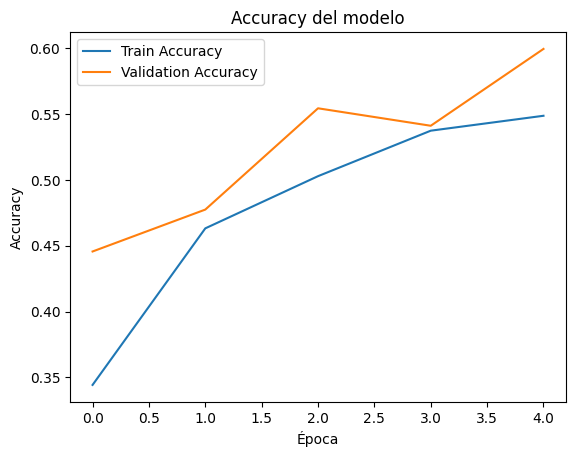

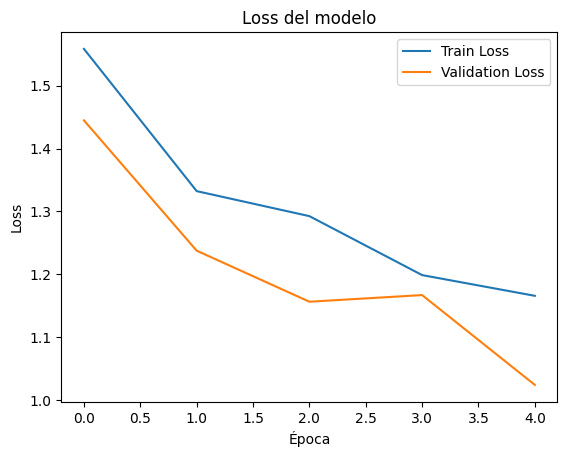

In [13]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy del modelo")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss del modelo")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test accuracy:", test_accuracy)
print("Test loss:", test_loss)

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - accuracy: 0.5781 - loss: 1.0959
Test accuracy: 0.578125
Test loss: 1.095917820930481


In [15]:
model.save("modelo_guardado/trashnet_tensorflow.keras")
print("Modelo guardado correctamente.")

Modelo guardado correctamente.
